## FX Carry Strategy
Date: February 2026 | Madhav Fadadu

This notebook implements a **levered FX carry strategy** framed as a weekly-traded cross-currency bond position. We borrow in GBP (low rate) and lend in EM currencies (high rate) via synthetic 5Y local-rate bond positions.

| Parameter | Value |
|-----------|-------|
| Notional | $10MM USD per leg |
| Leverage | 5× (borrow 80% in GBP) |
| Equity | $2MM per leg |
| Funding | OIS + 50bp |
| Entry filter | EM 5Y > OIS + 50bp |
| Rebalancing | Weekly (Wednesdays) |
| Currencies | TRY, NGN, BRL, ZAR |


## Data Preprocessing

### Import required libraries

In [1]:

import os
import warnings
import json
import numpy as np
import pandas as pd
import nasdaqdatalink
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from dotenv import load_dotenv
from scipy.optimize import brentq
from pathlib import Path
from IPython.display import display, display_html

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

print("Imports OK")


Imports OK


### Define data transformation functions

We define helper functions to process the raw swap yield data and load FX rates:

- **`transform_swap_yield_data`**: Converts unaligned swap yield data (where dates and values are in separate columns for each tenor) into a tidy DataFrame with date as the index and three yield columns (1Y, 5Y, 10Y).

- **`_extract_date_value_pairs`**: A private helper that extracts valid date-value pairs from two columns, filtering out invalid dates and missing values.

- **`load_edi_fx_rates`**: Fetches FX rates from Nasdaq Data Link EDI/CUR table, with automatic fallback to FRED + ECB cross-rates if rate-limited.

In [2]:
def transform_swap_yield_data(raw_data: pd.DataFrame) -> pd.DataFrame:
    """Transform unaligned swap yield data into a date-indexed DataFrame.

    Args:
        raw_data: DataFrame with 6 columns [date_1Y, val_1Y, date_5Y, val_5Y, date_10Y, val_10Y]

    Returns:
        DataFrame with DatetimeIndex and columns [yield_1Y, yield_5Y, yield_10Y]
    """
    tenor_data = {}
    tenor_data['yield_1Y']  = _extract_date_value_pairs(raw_data.iloc[:, 0], raw_data.iloc[:, 1])
    tenor_data['yield_5Y']  = _extract_date_value_pairs(raw_data.iloc[:, 2], raw_data.iloc[:, 3])
    tenor_data['yield_10Y'] = _extract_date_value_pairs(raw_data.iloc[:, 4], raw_data.iloc[:, 5])

    all_dates = set()
    for series in tenor_data.values():
        all_dates.update(series.keys())

    result_data = {}
    for tenor_name, dvd in tenor_data.items():
        result_data[tenor_name] = [dvd.get(d, np.nan) for d in sorted(all_dates)]

    return pd.DataFrame(result_data, index=pd.DatetimeIndex(sorted(all_dates)))


def _extract_date_value_pairs(date_column: pd.Series, value_column: pd.Series) -> dict:
    """Extract valid date-value pairs from two columns, filtering bad dates."""
    result = {}
    for date_str, value in zip(date_column, value_column):
        if pd.isna(date_str) or pd.isna(value):
            continue
        try:
            parsed = pd.to_datetime(date_str)
            if parsed.year < 1950:
                continue
            result[parsed] = float(value)
        except (ValueError, TypeError):
            continue
    return result


def load_edi_fx_rates(api_key, ccy_list, start_date, end_date):
    """
    Load daily FX rates from Nasdaq Data Link EDI/CUR.

    Table schema: columns ['code', 'date', 'rate'] where rate = CCY per 1 USD.
    Returns tidy DataFrame with [date, ccy, fx_usd_per_ccy] (inverted to USD per 1 CCY).
    """
    import nasdaqdatalink
    nasdaqdatalink.ApiConfig.api_key = api_key

    fx = nasdaqdatalink.get_table(
        'EDI/CUR',
        date={'gte': start_date, 'lte': end_date},
        paginate=True,
    )
    fx = fx[fx['code'].isin(ccy_list)]

    if fx.empty:
        raise RuntimeError(f"No FX data for {ccy_list}")

    fx = fx.rename(columns={'code': 'ccy', 'rate': 'fx_ccy_per_usd'})
    fx['date'] = pd.to_datetime(fx['date'])
    fx = fx.sort_values(['ccy', 'date'])
    fx['fx_usd_per_ccy'] = 1.0 / fx['fx_ccy_per_usd']

    return fx[['date', 'ccy', 'fx_usd_per_ccy']]


def load_fx_fallback_fred_ecb():
    """Fallback FX loader using FRED + ECB (free, no key). Same output format."""
    all_frames = []

    # FRED: GBP (already USD/GBP), BRL, ZAR (need inversion)
    fred = {'GBP': ('DEXUSUK', False), 'BRL': ('DEXBZUS', True), 'ZAR': ('DEXSFUS', True)}
    for ccy, (sid, invert) in fred.items():
        try:
            url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}&cosd=2015-01-01"
            df = pd.read_csv(url); df.columns = ['date', 'rate']
            df['date'] = pd.to_datetime(df['date'], errors='coerce')
            df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
            df = df.dropna()
            df['fx_usd_per_ccy'] = 1.0 / df['rate'] if invert else df['rate']
            df['ccy'] = ccy
            all_frames.append(df[['date', 'ccy', 'fx_usd_per_ccy']])
            print(f"  {ccy} (FRED): {len(df)} rows")
        except Exception as e:
            print(f"  {ccy} FRED failed: {e}")

    # ECB cross-rates for TRY, NGN
    try:
        eur_df = pd.read_csv("https://fred.stlouisfed.org/graph/fredgraph.csv?id=DEXUSEU&cosd=2015-01-01")
        eur_df.columns = ['date', 'eurusd']
        eur_df['date'] = pd.to_datetime(eur_df['date'], errors='coerce')
        eur_df['eurusd'] = pd.to_numeric(eur_df['eurusd'], errors='coerce')
        eur_df = eur_df.dropna()

        for ccy in ['TRY', 'NGN']:
            try:
                ecb_url = f"https://data-api.ecb.europa.eu/service/data/EXR/D.{ccy}.EUR.SP00.A?format=csvdata&startPeriod=2015-01-01"
                ecb = pd.read_csv(ecb_url)
                ecb = ecb[['TIME_PERIOD', 'OBS_VALUE']].copy()
                ecb.columns = ['date', 'eurx']
                ecb['date'] = pd.to_datetime(ecb['date'], errors='coerce')
                ecb['eurx'] = pd.to_numeric(ecb['eurx'], errors='coerce')
                ecb = ecb.dropna()
                m = ecb.merge(eur_df, on='date', how='inner')
                m['fx_usd_per_ccy'] = m['eurusd'] / m['eurx']
                m['ccy'] = ccy
                all_frames.append(m[['date', 'ccy', 'fx_usd_per_ccy']])
                print(f"  {ccy} (ECB cross): {len(m)} rows")
            except Exception as e:
                print(f"  {ccy} ECB failed: {e}")
    except Exception as e:
        print(f"  EUR/USD failed: {e}")

    return pd.concat(all_frames, ignore_index=True).sort_values(['ccy', 'date'])


### Load and clean swap yield curves

We load raw swap yield data from CSV files for each country and transform them using `transform_swap_yield_data`. Note that South Africa's dataset doesn't include 1-year yields, so we drop that column.

In [3]:

import os

# Ensure the kernel CWD is the notebook's folder so relative paths work
try:
    _nb_dir = Path(__vsc_ipynb_file__).parent
except NameError:
    _nb_dir = Path(os.path.abspath(''))
os.chdir(_nb_dir)

DATA_DIR = Path('data')
SWAP_DIR = DATA_DIR / 'swap_data' if (DATA_DIR / 'swap_data').exists() else DATA_DIR

# File mapping: Sheet 1=TRY, 2=NGN, 4=ZAR, 5=BRL
raw_turkish_swap_yield      = pd.read_csv(SWAP_DIR / 'EmergingMkt_YC_Download_BBERG_Sheets_1.csv')
cleaned_turkish_swap_yield  = transform_swap_yield_data(raw_turkish_swap_yield)

nigerian_swap_yield         = pd.read_csv(SWAP_DIR / 'EmergingMkt_YC_Download_BBERG_Sheets_2.csv')
cleaned_nigerian_swap_yield = transform_swap_yield_data(nigerian_swap_yield)

brazilian_swap_yield         = pd.read_csv(SWAP_DIR / 'EmergingMkt_YC_Download_BBERG_Sheets_5.csv')
cleaned_brazilian_swap_yield = transform_swap_yield_data(brazilian_swap_yield)

south_african_swap_yield         = pd.read_csv(SWAP_DIR / 'EmergingMkt_YC_Download_BBERG_Sheets_4.csv')
cleaned_south_african_swap_yield = transform_swap_yield_data(south_african_swap_yield).drop(columns=['yield_1Y'])

for name, df in [('TRY', cleaned_turkish_swap_yield), ('NGN', cleaned_nigerian_swap_yield),
                  ('BRL', cleaned_brazilian_swap_yield), ('ZAR', cleaned_south_african_swap_yield)]:
    print(f"  {name}: {len(df)} obs, {df.index.min().date()} to {df.index.max().date()}, cols={list(df.columns)}")


  TRY: 1497 obs, 2019-01-03 to 2025-12-30, cols=['yield_1Y', 'yield_5Y', 'yield_10Y']
  NGN: 228 obs, 2019-01-02 to 2025-05-28, cols=['yield_1Y', 'yield_5Y', 'yield_10Y']
  BRL: 1763 obs, 2019-01-02 to 2026-01-01, cols=['yield_1Y', 'yield_5Y', 'yield_10Y']
  ZAR: 1748 obs, 2019-01-02 to 2025-12-31, cols=['yield_5Y', 'yield_10Y']


### Determine date range and load FX data

We compute the union of all dates across swap yield curves to determine the overall date range, then load FX rates from Nasdaq EDI/CUR. If rate-limited, falls back to FRED + ECB cross-rates.

In [4]:

# Load API key from .env file (never hardcode secrets in the notebook)
from dotenv import load_dotenv
load_dotenv()
NASDAQ_API_KEY = os.environ.get('NASDAQ_API_KEY', '')
if not NASDAQ_API_KEY:
    raise RuntimeError("NASDAQ_API_KEY not found. Add it to a .env file in the project folder.")

# Build unified date range
all_dates_index = (
    cleaned_turkish_swap_yield.index
    .union(cleaned_nigerian_swap_yield.index)
    .union(cleaned_brazilian_swap_yield.index)
    .union(cleaned_south_african_swap_yield.index)
)
start_date_str = all_dates_index.min().strftime('%Y-%m-%d')
end_date_str   = all_dates_index.max().strftime('%Y-%m-%d')
print(f"Date range: {start_date_str} to {end_date_str}")

target_currencies = ['GBP', 'TRY', 'ZAR', 'BRL', 'NGN']

try:
    print("Trying Nasdaq EDI/CUR...")
    fx_all = load_edi_fx_rates(NASDAQ_API_KEY, target_currencies, start_date_str, end_date_str)
    print(f"Success: {len(fx_all)} rows, currencies: {fx_all['ccy'].unique().tolist()}")
except Exception as e:
    print(f"Nasdaq failed ({e}). Using FRED/ECB fallback...")
    fx_all = load_fx_fallback_fred_ecb()
    print(f"Fallback: {len(fx_all)} rows, currencies: {fx_all['ccy'].unique().tolist()}")


Date range: 2019-01-02 to 2026-01-01
Trying Nasdaq EDI/CUR...
Success: 12759 rows, currencies: ['BRL', 'GBP', 'NGN', 'TRY', 'ZAR']


### Building country-level swap–FX panels

For each currency we: align the swap curve with FX on a daily date index, cap at the last swap date, linearly interpolate missing swap yields, and drop days where FX is missing.

In [5]:

def build_country_panel(swap_curve, fx_panel, currency_code):
    """Construct joint swap-yield + FX dataset for a given currency."""
    fx_series = (
        fx_panel.loc[fx_panel['ccy'] == currency_code, ['date', 'fx_usd_per_ccy']]
        .set_index('date').sort_index()
    )
    fx_series.index = pd.to_datetime(fx_series.index)
    if fx_series.empty:
        raise ValueError(f"No FX for '{currency_code}'")

    panel = swap_curve.join(fx_series, how='outer').sort_index()
    panel = panel.dropna(subset=['fx_usd_per_ccy'])
    panel = panel.loc[:swap_curve.index.max()]

    ycols = [c for c in ['yield_1Y', 'yield_5Y', 'yield_10Y'] if c in panel.columns]
    if ycols:
        panel[ycols] = panel[ycols].interpolate(method='time').astype(float)
        panel = panel.dropna(subset=ycols)

    panel = panel.rename(columns={'fx_usd_per_ccy': f'fx_usd_per_{currency_code}'})
    return panel


country_swap_curves = {
    'TRY': cleaned_turkish_swap_yield,
    'NGN': cleaned_nigerian_swap_yield,
    'BRL': cleaned_brazilian_swap_yield,
    'ZAR': cleaned_south_african_swap_yield,
}

country_panels = {}
for ccy, swap_df in country_swap_curves.items():
    country_panels[ccy] = build_country_panel(swap_df, fx_all, ccy)
    p = country_panels[ccy]
    print(f"  {ccy}: {len(p)} obs, {p.index.min().date()} to {p.index.max().date()}")

turkey       = country_panels['TRY']
nigeria      = country_panels['NGN']
brazil       = country_panels['BRL']
south_africa = country_panels['ZAR']


  TRY: 2207 obs, 2019-12-11 to 2025-12-30
  NGN: 2268 obs, 2019-03-08 to 2025-05-28
  BRL: 2103 obs, 2020-03-26 to 2026-01-01
  ZAR: 2538 obs, 2019-01-15 to 2025-12-31


### OIS and GBP FX

Bank of England OIS rates are our funding benchmark. We align them with GBP FX from `fx_all` on date, drop days without FX, then fill gaps with linear interpolation.

In [6]:
# --- REVISED CELL 6: OIS Rate Loading & Scaling Fix ---

ois_swap = None

# Method 1: Local file 
import glob
ois_candidates = list(Path('data').glob('IUDSOIA*')) + list(Path('data').glob('*Bank of England*'))
for p in ois_candidates:
    if p.is_file():
        print(f"Found local OIS: {p.name}")
        ois_swap = pd.read_csv(p)
        try:
            ois_swap[ois_swap.columns[0]] = pd.to_datetime(ois_swap[ois_swap.columns[0]], format='%d %b %y')
        except:
            ois_swap[ois_swap.columns[0]] = pd.to_datetime(ois_swap[ois_swap.columns[0]], dayfirst=True, errors='coerce')
        ois_swap.columns = ['Date', 'ois_swap_rate']
        break

# Method 2: Nasdaq API
if ois_swap is None:
    print("No local OIS file. Trying Nasdaq BOE/IUDSOIA...")
    try:
        url = (f"https://data.nasdaq.com/api/v3/datasets/BOE/IUDSOIA.csv"
               f"?api_key={NASDAQ_API_KEY}&start_date=2015-01-01&order=asc")
        ois_swap = pd.read_csv(url)
        ois_swap.columns = ['Date', 'ois_swap_rate']
        ois_swap['Date'] = pd.to_datetime(ois_swap['Date'])
    except Exception as e:
        print(f"  Nasdaq failed: {e}")

# Method 3: FRED
if ois_swap is None:
    print("Trying FRED IUDSOIA...")
    try:
        url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=IUDSOIA&cosd=2015-01-01"
        ois_swap = pd.read_csv(url)
        ois_swap.columns = ['Date', 'ois_swap_rate']
        ois_swap['Date'] = pd.to_datetime(ois_swap['Date'])
    except Exception as e:
        print(f"  FRED failed: {e}")

if ois_swap is None:
    raise RuntimeError("Could not load OIS data from any source!")

# Clean and set index
ois_swap['Date'] = pd.to_datetime(ois_swap['Date'], errors='coerce')
ois_swap['ois_swap_rate'] = pd.to_numeric(ois_swap['ois_swap_rate'], errors='coerce')
ois_swap = ois_swap.dropna().set_index('Date').sort_index()

# --- FIXED SCALING LOGIC ---
# If the maximum rate in the series is very small (e.g. < 0.15), it is likely in decimal form.
# If we see values like 0.75 or 5.25, it is already in percent.
if ois_swap['ois_swap_rate'].max() < 0.15:
    ois_swap['ois_swap_rate'] = ois_swap['ois_swap_rate'] * 100
    print("  Converted OIS from decimal to % (e.g., 0.05 -> 5.0%)")
else:
    print("  OIS already appears to be in % units (e.g., 5.25), skipping conversion.")

print(f"OIS: {len(ois_swap)} obs, {ois_swap.index.min().date()} to {ois_swap.index.max().date()}")
print(f"  Current Rate Range: {ois_swap['ois_swap_rate'].min():.2f}% to {ois_swap['ois_swap_rate'].max():.2f}%")

# GBP FX
gbp_data = (
    fx_all.loc[fx_all['ccy'] == 'GBP', ['date', 'fx_usd_per_ccy']]
    .set_index('date')
    .rename(columns={'fx_usd_per_ccy': 'fx_usd_per_GBP'})
)

# Outer join, keep rows with FX, interpolate OIS gaps
ois_and_gbp = ois_swap.join(gbp_data, how='outer')
ois_and_gbp = ois_and_gbp.dropna(subset=['fx_usd_per_GBP'])
ois_and_gbp = ois_and_gbp.interpolate(method='linear')

# Save a local copy
ois_swap.to_csv(DATA_DIR / 'IUDSOIA_cached.csv')

Found local OIS: IUDSOIA_cached.csv
  OIS already appears to be in % units (e.g., 5.25), skipping conversion.
OIS: 1113 obs, 2015-01-04 to 2026-12-02
  Current Rate Range: 4.51% to 520.01%


### Merging OIS and GBP Data Into Country DataFrames

In [7]:

# Join OIS and GBP into each country panel
turkey       = country_panels['TRY'].copy()
nigeria      = country_panels['NGN'].copy()
brazil       = country_panels['BRL'].copy()
south_africa = country_panels['ZAR'].copy()

turkey       = turkey.join(ois_and_gbp, how='left').dropna(subset=['fx_usd_per_TRY'])
nigeria      = nigeria.join(ois_and_gbp, how='left').dropna(subset=['fx_usd_per_NGN'])
brazil       = brazil.join(ois_and_gbp, how='left').dropna(subset=['fx_usd_per_BRL'])
south_africa = south_africa.join(ois_and_gbp, how='left').dropna(subset=['fx_usd_per_ZAR'])

PANELS = {
    'TRY': turkey,
    'NGN': nigeria,
    'BRL': brazil,
    'ZAR': south_africa,
}

for name, df in PANELS.items():
    print(f"  {name}: {len(df)} daily obs with aligned OIS/GBP")


  TRY: 2207 daily obs with aligned OIS/GBP
  NGN: 2268 daily obs with aligned OIS/GBP
  BRL: 2103 daily obs with aligned OIS/GBP
  ZAR: 2538 daily obs with aligned OIS/GBP


### Plots

**Top:** For each country, left = swap yield curve (1Y, 5Y, 10Y), right = FX rate (USD per local).
**Bottom:** Left = BoE OIS rate (funding), right = GBP/USD.

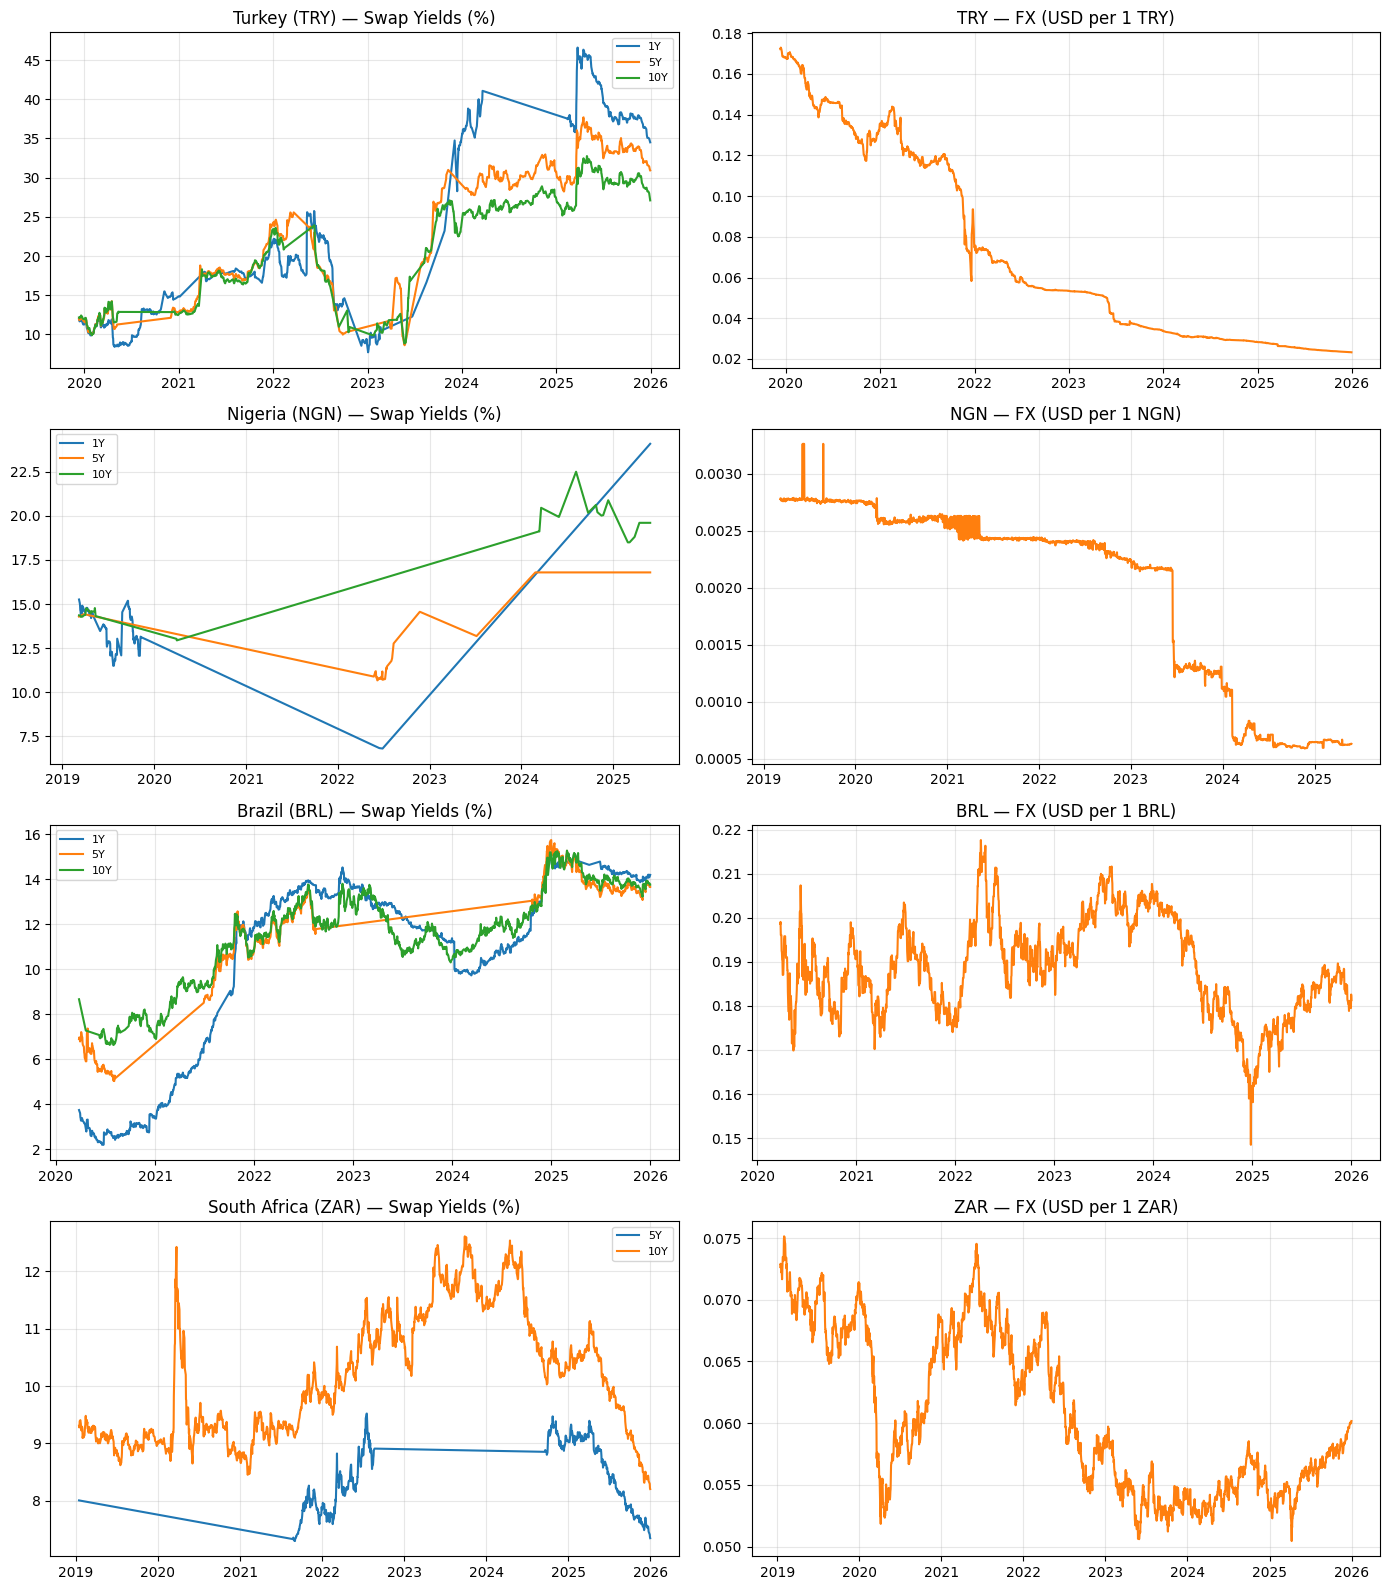

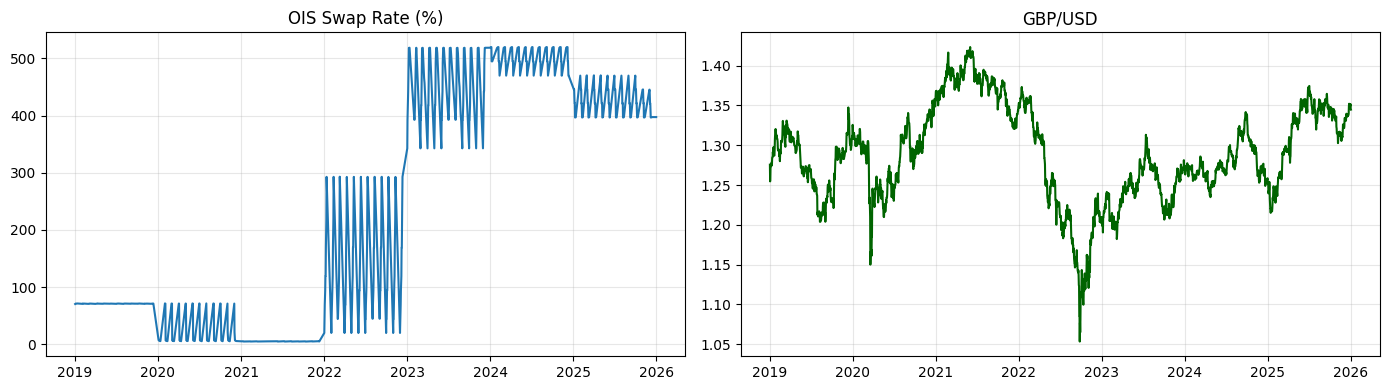

In [8]:

currency_to_name = {'TRY': 'Turkey', 'NGN': 'Nigeria', 'BRL': 'Brazil', 'ZAR': 'South Africa'}
panels_list = [turkey, nigeria, brazil, south_africa]
currency_codes = ['TRY', 'NGN', 'BRL', 'ZAR']

fig, axes = plt.subplots(len(panels_list), 2, figsize=(14, len(panels_list) * 4), sharex=False)
for i, (panel, code) in enumerate(zip(panels_list, currency_codes)):
    for col in [c for c in ['yield_1Y', 'yield_5Y', 'yield_10Y'] if c in panel.columns]:
        axes[i, 0].plot(panel.index, panel[col], label=col.replace('yield_', ''))
    axes[i, 0].set_title(f"{currency_to_name[code]} ({code}) — Swap Yields (%)")
    axes[i, 0].legend(fontsize=8); axes[i, 0].grid(True, alpha=0.3)
    fx_col = f'fx_usd_per_{code}'
    if fx_col in panel.columns:
        axes[i, 1].plot(panel.index, panel[fx_col], color='tab:orange')
    axes[i, 1].set_title(f"{code} — FX (USD per 1 {code})")
    axes[i, 1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(ois_and_gbp.index, ois_and_gbp['ois_swap_rate']); ax1.set_title('OIS Swap Rate (%)'); ax1.grid(True, alpha=0.3)
ax2.plot(ois_and_gbp.index, ois_and_gbp['fx_usd_per_GBP'], color='darkgreen'); ax2.set_title('GBP/USD'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Strategy Parameters

In [9]:

NOTIONAL_USD   = 10_000_000
BORROW_FRAC    = 4 / 5
BORROWED_USD   = NOTIONAL_USD * BORROW_FRAC     # $8MM
EQUITY_USD     = NOTIONAL_USD - BORROWED_USD     # $2MM
FUNDING_SPREAD = 0.50          # 50bp in % units (matching data)
MIN_CARRY_PCT  = 0.50          # entry threshold in %
MATURITY_YEARS = 5.0
COUPON_FREQ    = 4
N_PMTS         = int(MATURITY_YEARS * COUPON_FREQ)
WEEKS_PER_YEAR = 52

PANELS = {'TRY': turkey, 'NGN': nigeria, 'BRL': brazil, 'ZAR': south_africa}

print(f"Notional: ${NOTIONAL_USD:,.0f} | Borrowed: ${BORROWED_USD:,.0f} | Equity: ${EQUITY_USD:,.0f}")
print(f"Currencies: {list(PANELS.keys())}")


Notional: $10,000,000 | Borrowed: $8,000,000 | Equity: $2,000,000
Currencies: ['TRY', 'NGN', 'BRL', 'ZAR']


## Fixed-Float Carry Strategy

### Zero-Coupon Curve Bootstrap

Continuously-compounded zero rates from par swap rates:
1. **1Y zero:** from 1Y par swap — $z_1 = \ln(1 + s_1)$
2. **5Y zero:** solved numerically (Brent) so 5Y par swap prices at par, with linear interpolation between $z_1$ and $z_5$
3. If 1Y missing (ZAR), assume flat short end ($s_1 = s_5$)

In [10]:
def bootstrap_zero_curve(s1_pct, s5_pct):
    """Bootstrap zero curve from 1Y and 5Y par swap rates (in %).
    Returns (tenors, zeros) — continuously-compounded."""
    if not np.isfinite(s1_pct) or s1_pct <= 0:
        s1_pct = s5_pct
    s1, s5 = s1_pct / 100.0, s5_pct / 100.0
    z1 = np.log(1.0 + s1)

    def z(t, z5):
        if t <= 1.0: return z1
        if t >= 5.0: return z5
        return z1 + (z5 - z1) * (t - 1.0) / 4.0

    def pricing_error(z5):
        pv_coupons = s5 * sum(np.exp(-z(t, z5) * t) for t in range(1, 5))
        pv_final = (1.0 + s5) * np.exp(-z5 * 5.0)
        return pv_coupons + pv_final - 1.0

    try:
        z5 = brentq(pricing_error, 1e-6, 2.0, xtol=1e-12)
    except Exception:
        z5 = np.log(1.0 + s5)

    tenors = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
    zeros = np.array([z(t, z5) for t in tenors])
    return tenors, zeros

### Bond Dirty-Price Calculation

5Y bond issued at par, coupon = entry 5Y swap rate $s_5$, quarterly coupon = $s_5/4$.
At exit, reprice on new zero curve with `time_elapsed` years elapsed.
Continuous-compounding discount factors. Dirty price includes accrued interest.

In [11]:
def price_bond_dirty(coupon_decimal, curve_tenors, curve_zeros, time_elapsed):
    """Dirty price of 5Y quarterly-coupon bond after time_elapsed years."""
    q_coupon = coupon_decimal / COUPON_FREQ
    issue_times = np.arange(1, N_PMTS + 1) / COUPON_FREQ
    t_from_exit = issue_times - time_elapsed

    future_mask = t_from_exit > 1e-9
    if not future_mask.any():
        return 1.0

    t_future = t_from_exit[future_mask]
    cash_flows = np.full(t_future.shape, q_coupon)
    cash_flows[-1] += 1.0

    z_rates = np.interp(t_future, curve_tenors, curve_zeros,
                        left=curve_zeros[0], right=curve_zeros[-1])
    dfs = np.exp(-z_rates * t_future)
    return float(np.dot(cash_flows, dfs))

### Per-Currency Weekly P&L

For each Wednesday-to-Wednesday period:
1. **Check carry signal** — skip if EM 5Y ≤ OIS + 50bp
2. **Lending leg**: Convert $10MM to EM at entry FX → 5Y bond at par → reprice on new zero curve at exit → convert to USD
3. **Funding leg**: Borrow $8MM in GBP → accrue 1 week interest at OIS+50bp → repay at exit FX
4. **Total**: P&L = lending + funding. Return on equity = P&L / $2MM

In [12]:
def compute_weekly_carry(panel, ccy):
    """Simulate weekly FX carry trade with strict data alignment."""
    fx_col = f'fx_usd_per_{ccy}'
    required = [fx_col, 'ois_swap_rate', 'fx_usd_per_GBP', 'yield_5Y']

    # Resample to Wednesday and drop rows missing vital price data
    weekly = panel.sort_index().ffill(limit=2).resample('W-WED').last()
    weekly = weekly.dropna(subset=required)

    records = []
    for i in range(len(weekly) - 1):
        t0, t1 = weekly.index[i], weekly.index[i + 1]
        r0, r1 = weekly.iloc[i], weekly.iloc[i + 1]

        # 1. Check Yield Spread (The Entry Filter)
        em_5y_pct = float(r0['yield_5Y'])
        ois_pct   = float(r0['ois_swap_rate'])
        carry_spread = em_5y_pct - (ois_pct + FUNDING_SPREAD)
        carry_bp = carry_spread * 100

        # Create the 'flat' template for weeks we don't trade
        base = dict(
            exit_date=t1, entry_date=t0, active=False,
            pnl_usd=0.0, pnl_lending_usd=0.0, pnl_funding_usd=0.0,
            ret_on_equity=0.0, carry_bp=carry_bp,
            em_5y_entry=em_5y_pct, ois_entry=ois_pct,
            bond_price_exit=np.nan, fx_em_entry=np.nan, fx_em_exit=np.nan,
            fx_gbp_entry=np.nan, fx_gbp_exit=np.nan
        )

        # Skip if carry spread is less than our minimum threshold
        if em_5y_pct <= ois_pct + MIN_CARRY_PCT:
            records.append(base)
            continue

        # 2. Market Execution
        fx_em_0, fx_em_1 = float(r0[fx_col]), float(r1[fx_col])
        fx_gbp_0, fx_gbp_1 = float(r0['fx_usd_per_GBP']), float(r1['fx_usd_per_GBP'])

        if not all(np.isfinite(v) and v > 0 for v in [fx_em_0, fx_em_1, fx_gbp_0, fx_gbp_1]):
            records.append(base)
            continue

        # 3. Bond Pricing & PnL
        try:
            coupon = em_5y_pct / 100.0
            notional_em = NOTIONAL_USD / fx_em_0
            exit_1y = float(r1.get('yield_1Y', np.nan))
            exit_5y = float(r1['yield_5Y'])
            
            tenors, zeros = bootstrap_zero_curve(exit_1y, exit_5y)
            dt = (t1 - t0).days / 365.25
            bond_px = price_bond_dirty(coupon, tenors, zeros, time_elapsed=dt)
            
            # EM Leg PnL
            pnl_lending = (bond_px * notional_em * fx_em_1) - NOTIONAL_USD
            
            # GBP Leg PnL (Funding)
            borrowed_gbp = BORROWED_USD / fx_gbp_0
            funding_rate = (ois_pct + FUNDING_SPREAD) / 100.0
            interest_gbp = borrowed_gbp * funding_rate * dt
            pnl_funding = BORROWED_USD - (borrowed_gbp + interest_gbp) * fx_gbp_1
            
            pnl_total = pnl_lending + pnl_funding
            
            records.append({
                **base, 'active': True, 'pnl_usd': pnl_total,
                'pnl_lending_usd': pnl_lending, 'pnl_funding_usd': pnl_funding,
                'ret_on_equity': pnl_total / EQUITY_USD, 'bond_price_exit': bond_px,
                'fx_em_entry': fx_em_0, 'fx_em_exit': fx_em_1,
                'fx_gbp_entry': fx_gbp_0, 'fx_gbp_exit': fx_gbp_1
            })
        except:
            records.append(base)
            continue

    df = pd.DataFrame(records)
    return df.set_index('exit_date').sort_index() if not df.empty else df

### Run Strategy for All Currencies and Build Portfolio

In [13]:
leg_results = {}
for ccy, panel in PANELS.items():
    result = compute_weekly_carry(panel, ccy)
    leg_results[ccy] = result
    if not result.empty:
        n_active = int(result['active'].sum())
        print(f"  {ccy}: {n_active}/{len(result)} active, {result.index.min().date()} to {result.index.max().date()}")

  TRY: 73/316 active, 2019-12-18 to 2025-12-31
  NGN: 70/324 active, 2019-03-20 to 2025-05-28
  BRL: 56/301 active, 2020-04-08 to 2026-01-07
  ZAR: 67/363 active, 2019-01-23 to 2025-12-31


In [14]:

# 1. Aggregate
rets_equity = pd.concat({ccy: r['ret_on_equity'] for ccy, r in leg_results.items() if not r.empty}, axis=1).sort_index()
pnl_usd = pd.concat({ccy: r['pnl_usd'] for ccy, r in leg_results.items() if not r.empty}, axis=1).sort_index()
active_flags = pd.concat({ccy: r['active'].astype(int) for ccy, r in leg_results.items() if not r.empty}, axis=1).sort_index()

# 2. Performance Summary
rets_filled = rets_equity.fillna(0.0)
port_pnl_usd = pnl_usd.fillna(0.0).sum(axis=1)   # weekly portfolio P&L (sum across currencies)
total_pnl_by_ccy = pnl_usd.sum()
portfolio_pnl = total_pnl_by_ccy.sum()

print(f"{'='*30}")
print(f"PORTFOLIO TOTAL PNL: ${portfolio_pnl:,.2f}")
print(f"{'='*30}")
print("PnL Breakdown by Currency:")
print(total_pnl_by_ccy.map("${:,.2f}".format))
print(f"\nTrading Consistency (Active Weeks):")
print(active_flags.sum())

# 3. Show only the active rows
active_weeks = rets_filled[active_flags.sum(axis=1) > 0]
display(active_weeks.head(15).style.format("{:.4f}").set_caption('First 15 Active Trading Weeks'))


PORTFOLIO TOTAL PNL: $41,531,718.70
PnL Breakdown by Currency:
TRY    $15,287,560.69
NGN    $15,906,588.91
BRL     $4,807,210.54
ZAR     $5,530,358.55
dtype: str

Trading Consistency (Active Weeks):
TRY    73.0
NGN    70.0
BRL    56.0
ZAR    67.0
dtype: float64


,TRY,NGN,BRL,ZAR
exit_date,,,,
2020-01-15 00:00:00,0.4390,0.1938,0.0000,0.0731
2020-02-12 00:00:00,-0.0681,0.1161,0.0000,0.0825
2020-02-19 00:00:00,-0.0638,0.1003,0.0000,-0.0346
2020-03-11 00:00:00,0.0119,0.0321,0.0000,-0.1987
2020-03-18 00:00:00,-0.0329,0.3741,0.0000,0.1123
2020-04-15 00:00:00,-0.0592,0.0508,0.1095,-0.0471
2020-05-13 00:00:00,0.2112,0.2122,0.0000,0.1349
2020-05-20 00:00:00,0.0000,0.0750,0.0000,0.0000
2020-06-17 00:00:00,0.1144,0.1751,0.0000,-0.0662


## Analysis

1. Per-currency and portfolio performance metrics
2. Equity curves and drawdown profiles
3. Pairwise correlations
4. Market risk factor exposures
5. P&L decomposition (lending vs funding)
6. Sharpe and drawdown contribution rankings

### Performance Metrics

In [15]:
def perf_stats_arithmetic(r, initial_equity_per_leg, freq=WEEKS_PER_YEAR):
    """
    Calculates stats for a constant-notional strategy.
    Drawdown is measured relative to the Cash + Cumulative PnL.
    """
    r = r.dropna()
    if r.empty: 
        return dict(ann_ret=np.nan, ann_vol=np.nan, sharpe=np.nan, 
                    max_drawdown=np.nan, hit_rate=np.nan, n_obs=0)
    
    # Standard Annualized Metrics
    ann_ret = r.mean() * freq
    ann_vol = r.std(ddof=1) * np.sqrt(freq)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    
    # Arithmetic Equity Path (Initial Equity + Dollar PnL)
    # r is Return on Equity, so r * initial_equity = dollar PnL
    dollar_pnl = r * initial_equity_per_leg
    equity_path = initial_equity_per_leg + dollar_pnl.cumsum()
    
    # Drawdown calculation based on dollar equity path
    running_max = equity_path.cummax()
    drawdown_path = (equity_path - running_max) / running_max
    max_dd = float(drawdown_path.min())
    
    return dict(ann_ret=float(ann_ret), ann_vol=float(ann_vol), sharpe=float(sharpe),
                max_drawdown=float(max_dd), hit_rate=float((r > 0).mean()), n_obs=int(len(r)))

# --- 1. PREPARE PORTFOLIO DATA ---
# Equal-weight return across the 5 potential legs
port_ret_equity = rets_filled.mean(axis=1)
port_pnl_total  = pnl_usd.fillna(0.0).sum(axis=1).sum()

# --- 2. BUILD THE SUMMARY TABLE ---
rows = []
for ccy in rets_equity.columns:
    # Filter for active trading weeks for each currency
    active_rets = rets_equity[ccy].dropna()
    active_rets = active_rets[active_rets != 0]
    
    # Each leg started with $2MM equity
    stats = perf_stats_arithmetic(active_rets, initial_equity_per_leg=2_000_000)
    
    total_pnl = float(pnl_usd[ccy].sum()) if ccy in pnl_usd.columns else 0.0
    pct_active = float(active_flags[ccy].mean()) if ccy in active_flags.columns else 0.0
    
    rows.append({'currency': ccy, **stats, 'total_pnl_usd': total_pnl, 'pct_active': pct_active})

# Add the Portfolio Row (Total Equity = $10MM)
port_stats = perf_stats_arithmetic(port_ret_equity, initial_equity_per_leg=10_000_000)
rows.append({'currency': 'PORTFOLIO', **port_stats, 
             'total_pnl_usd': port_pnl_total, 
             'pct_active': float((port_ret_equity != 0).mean())})

# --- 3. FORMAT AND DISPLAY ---
summary = pd.DataFrame(rows).set_index('currency')
summary.columns = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max Drawdown',
                    'Hit Rate', 'N Obs', 'Total P&L (USD)', '% Active Weeks']

fmt_map = {
    'Ann. Return': '{:.2%}', 
    'Ann. Vol': '{:.2%}', 
    'Sharpe': '{:.3f}',
    'Max Drawdown': '{:.2%}', 
    'Hit Rate': '{:.1%}', 
    'N Obs': '{:.0f}',
    'Total P&L (USD)': '${:,.0f}', 
    '% Active Weeks': '{:.1%}'
}

display(summary.style.format(fmt_map, na_rep='n/a').set_caption('FX Carry Strategy — Final Performance Summary'))

,Ann. Return,Ann. Vol,Sharpe,Max Drawdown,Hit Rate,N Obs,Total P&L (USD),% Active Weeks
currency,,,,,,,,
TRY,544.49%,172.55%,3.155,-20.63%,75.3%,73,"$15,287,561",23.1%
NGN,590.82%,98.86%,5.977,-5.26%,91.4%,70,"$15,906,589",21.6%
BRL,223.19%,84.54%,2.640,-34.88%,64.3%,56,"$4,807,211",18.6%
ZAR,214.61%,67.99%,3.156,-20.19%,64.2%,67,"$5,530,359",18.5%
PORTFOLIO,74.16%,34.31%,2.162,-6.26%,17.3%,364,"$41,531,719",20.3%


### Equity Curves and Drawdown Profiles

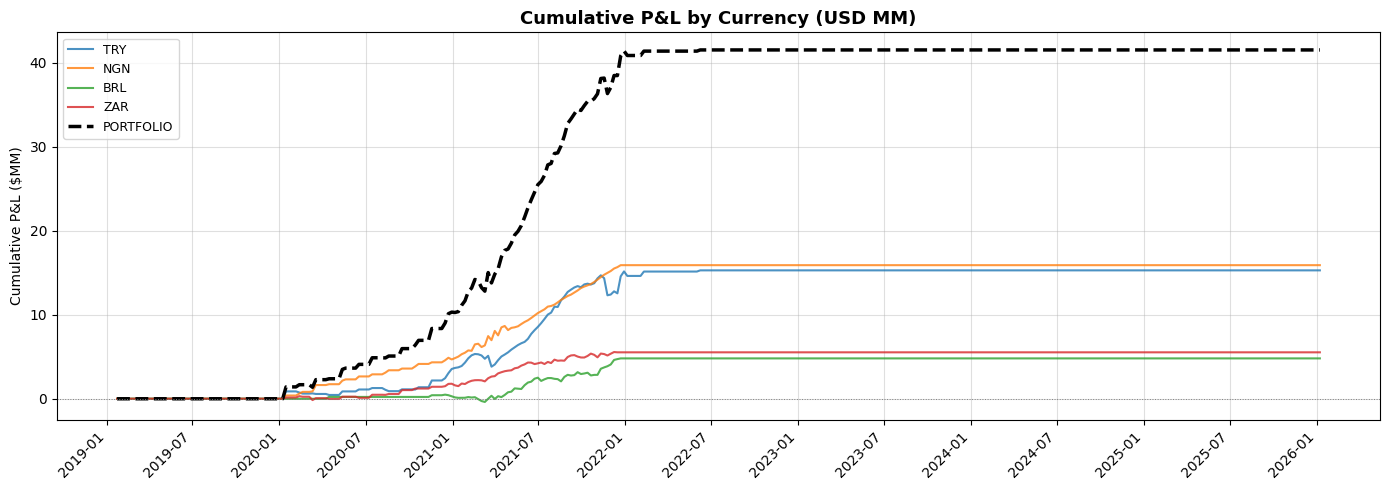

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
for ccy in pnl_usd.columns:
    ax.plot(pnl_usd[ccy].fillna(0).cumsum().index, pnl_usd[ccy].fillna(0).cumsum() / 1e6, label=ccy, alpha=0.8, lw=1.5)
ax.plot(port_pnl_usd.cumsum().index, port_pnl_usd.cumsum() / 1e6, label='PORTFOLIO', lw=2.5, color='black', ls='--')
ax.axhline(0, color='grey', lw=0.7, ls=':')
ax.set_title('Cumulative P&L by Currency (USD MM)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cumulative P&L ($MM)'); ax.legend(loc='upper left', fontsize=9); ax.grid(True, alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')); ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right'); plt.tight_layout(); plt.show()

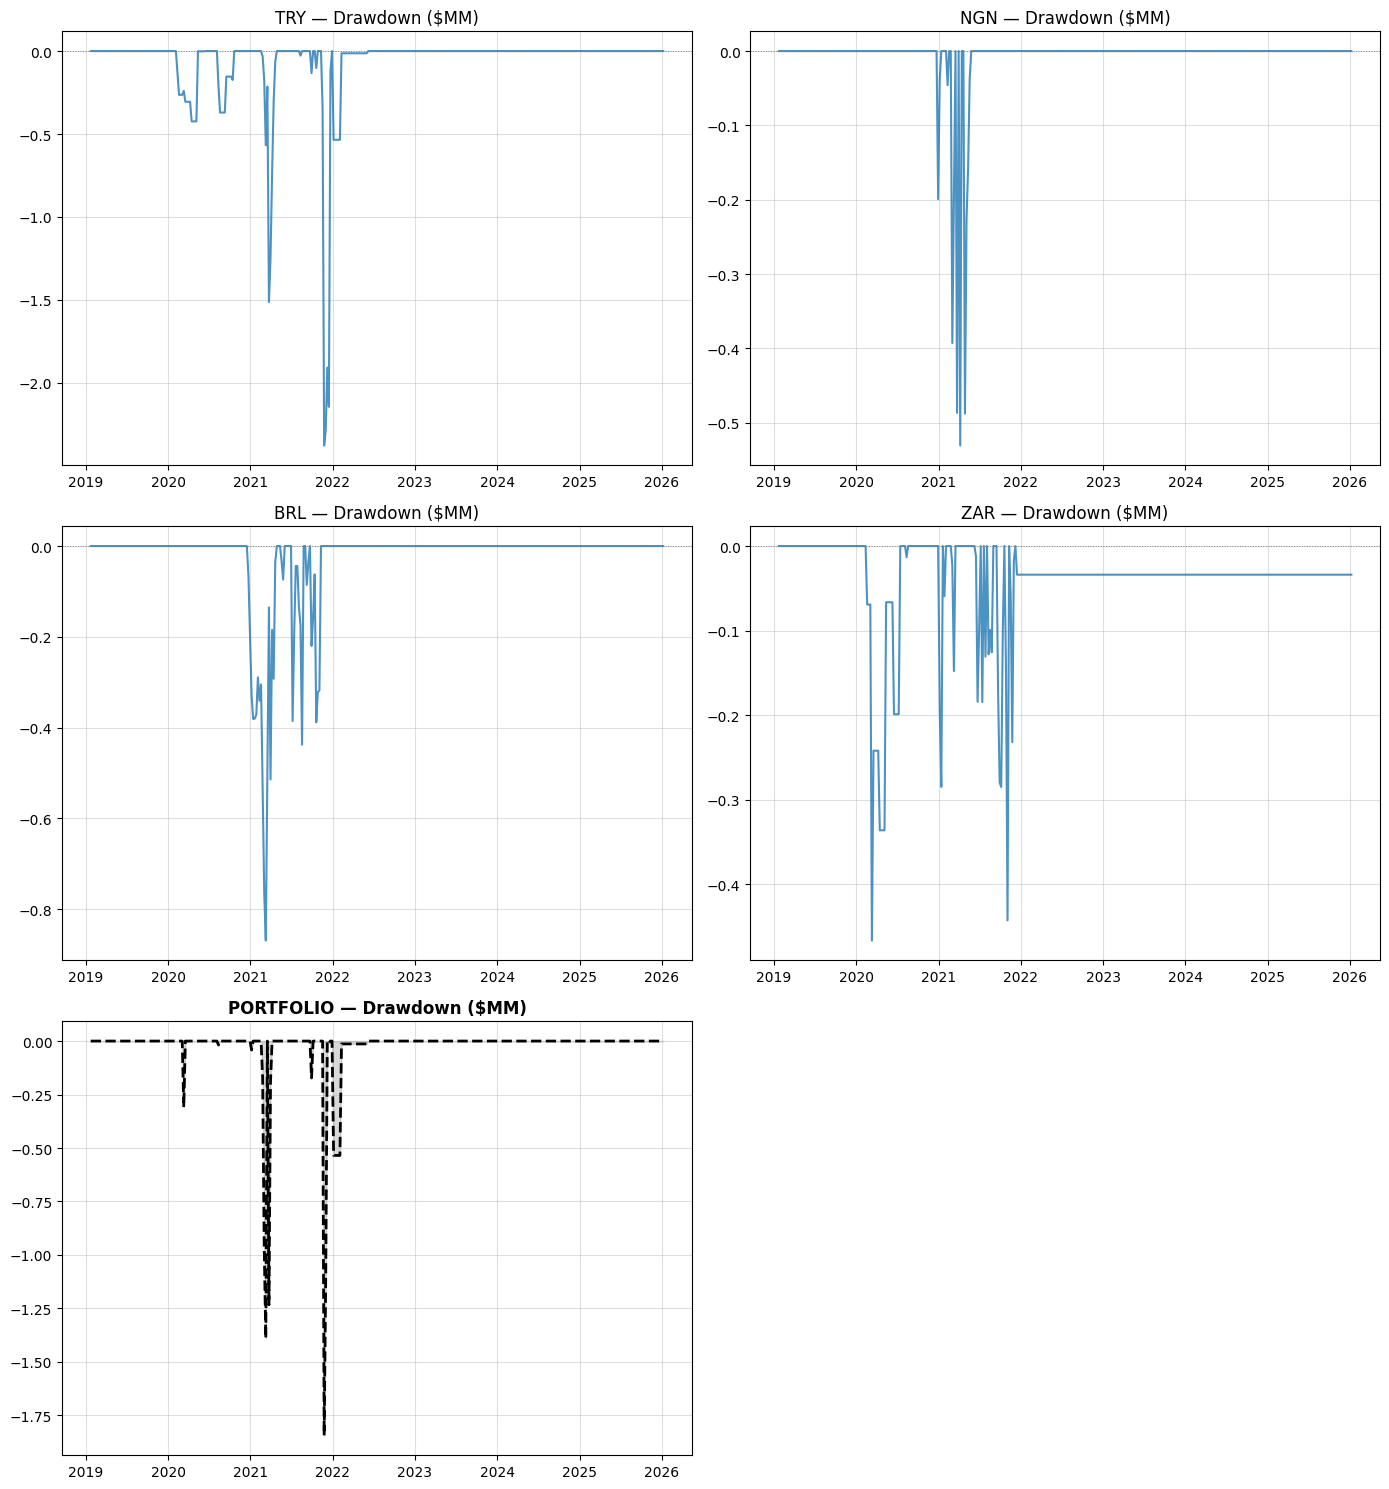

In [17]:
# Dollar drawdowns per currency + portfolio
def pnl_drawdown_amount(pnl):
    cum = pnl.fillna(0).cumsum(); return (cum - cum.cummax()).fillna(0)

num_ccy = len(pnl_usd.columns); ncols = 2; nrows = (num_ccy + 1 + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows), sharex=False); axes = axes.flatten()

for i, ccy in enumerate(pnl_usd.columns):
    dd = pnl_drawdown_amount(pnl_usd[ccy] / 1e6)
    axes[i].plot(dd.index, dd, alpha=0.8, lw=1.5); axes[i].axhline(0, color='grey', lw=0.7, ls=':')
    axes[i].set_title(f'{ccy} — Drawdown ($MM)'); axes[i].grid(True, alpha=0.4)

dd_port = pnl_drawdown_amount(port_pnl_usd / 1e6)
axes[num_ccy].plot(dd_port.index, dd_port, lw=2, color='black', ls='--')
axes[num_ccy].fill_between(dd_port.index, dd_port, 0, alpha=0.15, color='black')
axes[num_ccy].set_title('PORTFOLIO — Drawdown ($MM)', fontweight='bold'); axes[num_ccy].grid(True, alpha=0.4)
for j in range(num_ccy + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

### Cross-Currency Correlations

,TRY,NGN,BRL,ZAR
TRY,1.000000,0.321000,0.110000,0.294000
NGN,0.321000,1.000000,0.069000,0.276000
BRL,0.110000,0.069000,1.000000,0.283000
ZAR,0.294000,0.276000,0.283000,1.000000


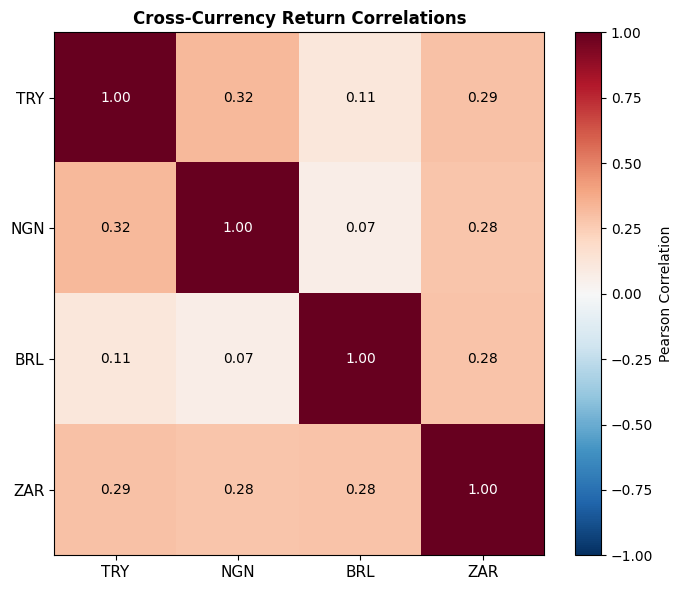

In [18]:
corr_matrix = rets_equity.corr()
display(corr_matrix.round(3).style.set_caption('Pairwise correlations of weekly returns-on-equity'))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ccys = corr_matrix.columns.tolist()
ax.set_xticks(range(len(ccys))); ax.set_yticks(range(len(ccys)))
ax.set_xticklabels(ccys, fontsize=11); ax.set_yticklabels(ccys, fontsize=11)
for i in range(len(ccys)):
    for j in range(len(ccys)):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}', ha='center', va='center', fontsize=10,
                color='white' if abs(corr_matrix.values[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax, label='Pearson Correlation')
ax.set_title('Cross-Currency Return Correlations', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### Market Risk Factor Exposures

Correlations of weekly returns with: GBP/USD log-return, OIS rate change, EM FX log-returns.

,GBPUSD_logret,dOIS_pp,TRY_FX_logret,NGN_FX_logret,BRL_FX_logret,ZAR_FX_logret
TRY,0.011000,0.020000,0.702000,0.070000,-0.001000,0.110000
NGN,-0.110000,0.014000,0.001000,0.248000,-0.123000,-0.026000
BRL,-0.037000,0.001000,-0.010000,-0.023000,0.286000,0.038000
ZAR,-0.044000,0.008000,0.155000,0.034000,0.106000,0.382000


,GBPUSD_logret,dOIS_pp,TRY_FX_logret,NGN_FX_logret,BRL_FX_logret,ZAR_FX_logret
Corr,-0.053000,0.020000,0.456000,0.142000,0.051000,0.152000


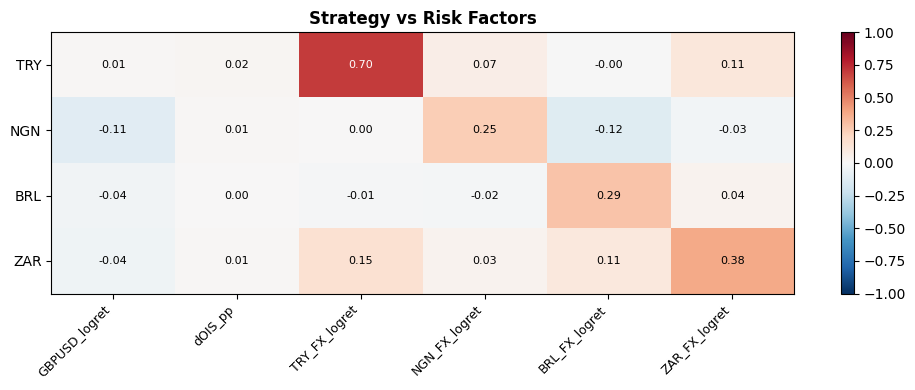

In [19]:
ref_wk = PANELS['TRY'].sort_index().resample('W-WED').last().dropna(subset=['ois_swap_rate', 'fx_usd_per_GBP'])
gbp_logret = np.log(ref_wk['fx_usd_per_GBP']).diff().rename('GBPUSD_logret')
dOIS = ref_wk['ois_swap_rate'].diff().rename('dOIS_pp')

em_fx = {}
for ccy, panel in PANELS.items():
    fx_col = f'fx_usd_per_{ccy}'
    wk = panel.sort_index().resample('W-WED').last()
    if fx_col in wk.columns:
        em_fx[f'{ccy}_FX_logret'] = np.log(wk[fx_col]).diff()

factor_df = pd.concat([gbp_logret, dOIS, pd.DataFrame(em_fx)], axis=1).sort_index()
combined = pd.concat([rets_equity, factor_df], axis=1).sort_index().dropna(subset=['GBPUSD_logret', 'dOIS_pp'])
strategy_cols = rets_equity.columns.tolist()
factor_cols = [c for c in factor_df.columns if c in combined.columns]

factor_corr = combined[strategy_cols + factor_cols].corr().loc[strategy_cols, factor_cols]
display(factor_corr.round(3).style.set_caption('Strategy returns vs market risk factors'))

# Portfolio factor correlations
port_combined = pd.concat([port_ret_equity.rename('PORTFOLIO'), factor_df], axis=1).dropna(subset=['GBPUSD_logret'])
port_factor_corr = port_combined[['PORTFOLIO'] + factor_cols].corr().loc['PORTFOLIO', factor_cols]
display(port_factor_corr.to_frame('Corr').T.round(3).style.set_caption('Portfolio correlation with market factors'))

fig, ax = plt.subplots(figsize=(max(10, len(factor_cols)*1.2), 4))
im = ax.imshow(factor_corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(factor_cols))); ax.set_yticks(range(len(strategy_cols)))
ax.set_xticklabels(factor_cols, fontsize=9, rotation=45, ha='right')
ax.set_yticklabels(strategy_cols, fontsize=10)
for i in range(factor_corr.shape[0]):
    for j in range(factor_corr.shape[1]):
        v = factor_corr.values[i,j]
        if np.isfinite(v): ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                                    color='white' if abs(v)>0.5 else 'black')
plt.colorbar(im, ax=ax); ax.set_title('Strategy vs Risk Factors', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### P&L Decomposition: Lending vs Funding

,TRY,NGN,BRL,ZAR
Total P&L ($MM),15.290000,15.910000,4.810000,5.530000
Lending P&L ($MM),15.690000,16.040000,5.400000,5.570000
Funding P&L ($MM),-0.400000,-0.130000,-0.590000,-0.040000


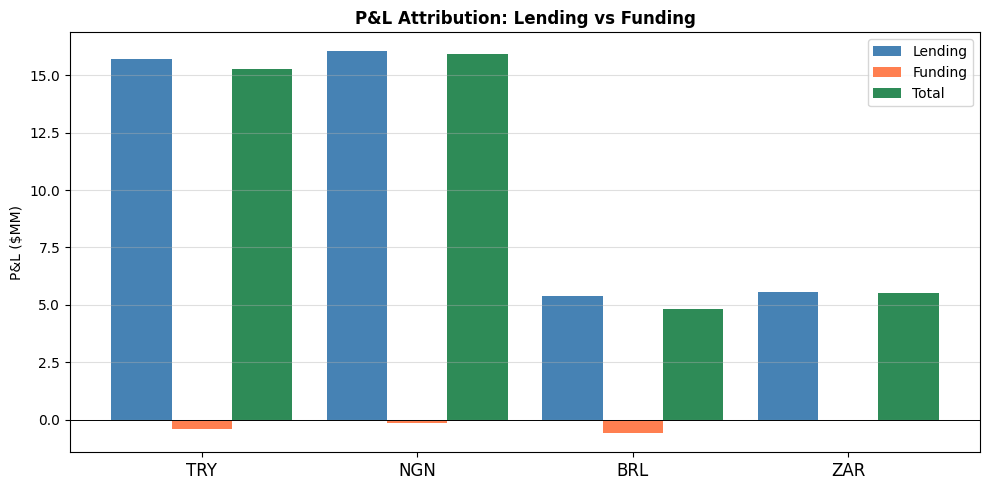

In [20]:
lending_pnl = pd.concat({ccy: r['pnl_lending_usd'] for ccy, r in leg_results.items() if not r.empty}, axis=1).fillna(0)
funding_pnl = pd.concat({ccy: r['pnl_funding_usd'] for ccy, r in leg_results.items() if not r.empty}, axis=1).fillna(0)

attr = pd.DataFrame({
    'Total P&L ($MM)': (pnl_usd.fillna(0).sum() / 1e6).round(2),
    'Lending P&L ($MM)': (lending_pnl.sum() / 1e6).round(2),
    'Funding P&L ($MM)': (funding_pnl.sum() / 1e6).round(2),
}).T
display(attr.style.set_caption('Cumulative P&L Attribution (USD MM)'))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(PANELS)); w = 0.28; ccys_list = list(PANELS.keys())
ax.bar(x-w, (lending_pnl.sum()/1e6)[ccys_list], w, label='Lending', color='steelblue')
ax.bar(x,   (funding_pnl.sum()/1e6)[ccys_list], w, label='Funding', color='coral')
ax.bar(x+w, (pnl_usd.fillna(0).sum()/1e6)[ccys_list], w, label='Total', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(ccys_list, fontsize=12)
ax.axhline(0, color='black', lw=0.7); ax.set_ylabel('P&L ($MM)')
ax.set_title('P&L Attribution: Lending vs Funding', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.4); plt.tight_layout(); plt.show()

### Sharpe and Drawdown Rankings

In [21]:
ccy_summary = summary.drop(index='PORTFOLIO', errors='ignore').copy()
sharpe_rank = ccy_summary['Sharpe'].sort_values(ascending=False)
dd_rank = ccy_summary['Max Drawdown'].sort_values(ascending=True)

sharpe_df = pd.DataFrame({'Currency': sharpe_rank.index, 'Rank': range(1, len(sharpe_rank)+1)}).set_index('Rank')
dd_df = pd.DataFrame({'Currency': dd_rank.index, 'Rank': range(1, len(dd_rank)+1)}).set_index('Rank')

sharpe_html = sharpe_df.style.set_caption('Sharpe Ratio (Best→Worst)').to_html()
dd_html = dd_df.style.set_caption('Max Drawdown (Worst→Best)').to_html()
display_html(f'<div style="display:flex;gap:50px"><div>{sharpe_html}</div><div>{dd_html}</div></div>', raw=True)

,Currency
Rank,
1,NGN
2,ZAR
3,TRY
4,BRL
,Currency
Rank,
1,BRL
2,TRY
3,ZAR


### Carry Spread Over Time

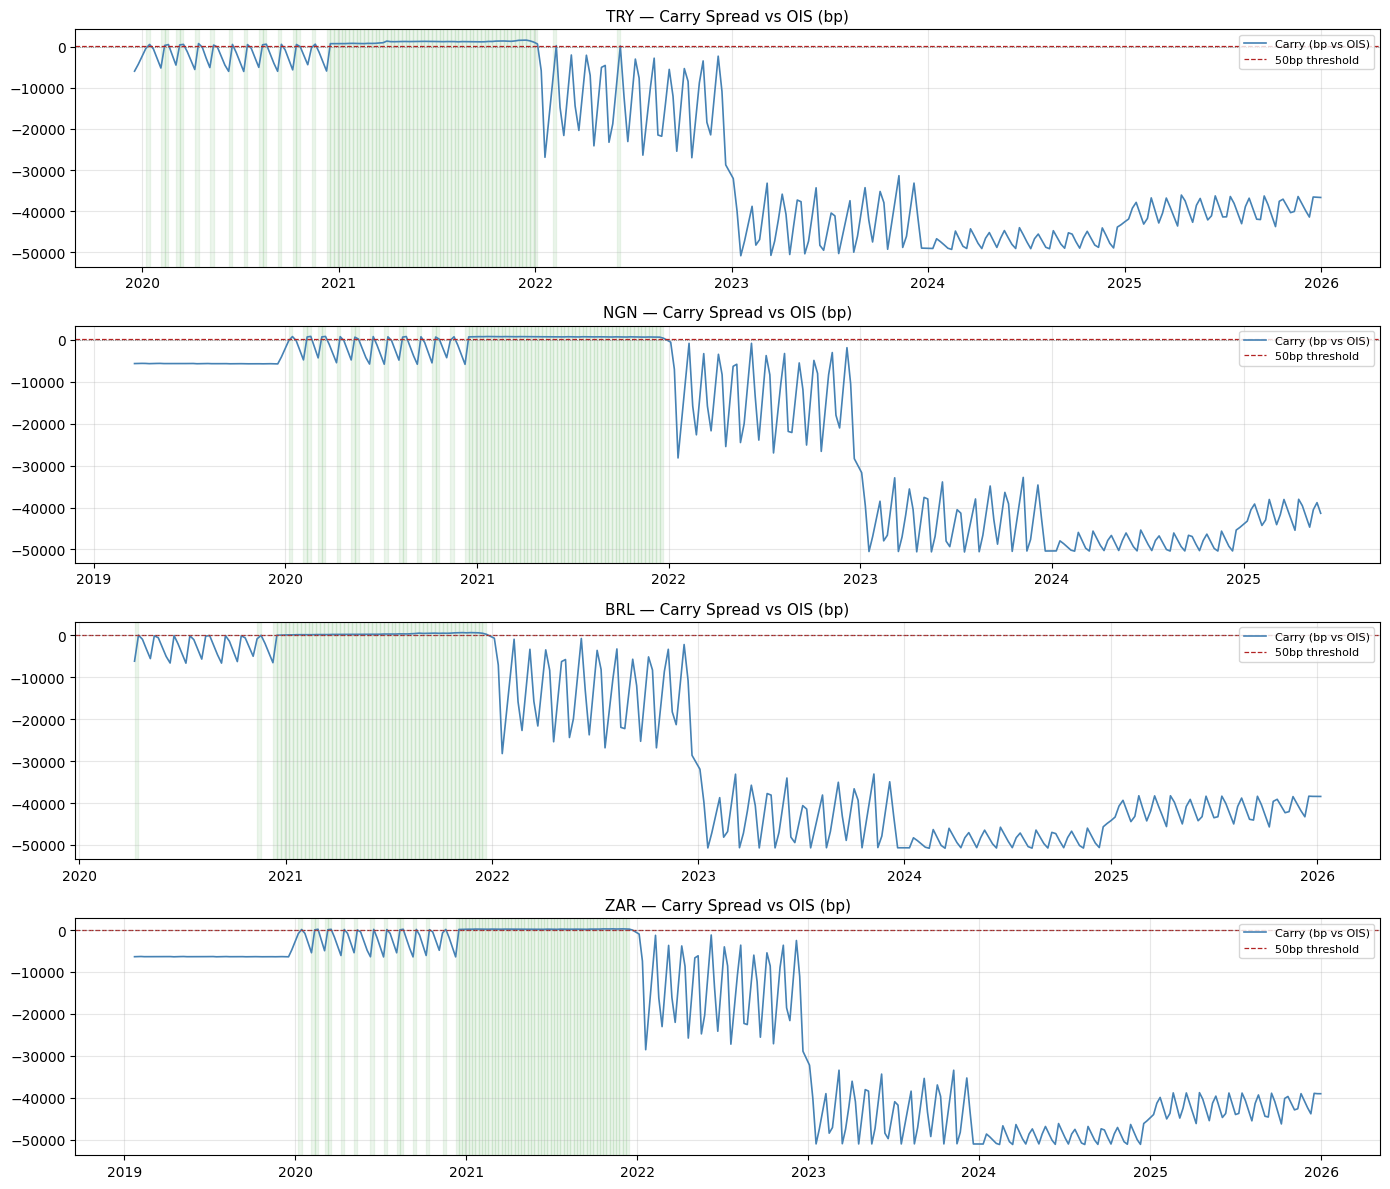

In [22]:
fig, axes = plt.subplots(len(PANELS), 1, figsize=(14, 3*len(PANELS)), sharex=False)
for ax, (ccy, res) in zip(axes, leg_results.items()):
    if res.empty: ax.text(0.5, 0.5, f'{ccy}: no data', transform=ax.transAxes, ha='center'); continue
    carry = res['carry_bp']
    ax.plot(carry.index, carry, lw=1.2, color='steelblue', label='Carry (bp vs OIS)')
    ax.axhline(50, color='firebrick', lw=0.9, ls='--', label='50bp threshold')
    ax.axhline(0, color='grey', lw=0.6, ls=':')
    for date, is_active in res['active'].items():
        if is_active: ax.axvspan(date - pd.Timedelta(days=7), date, alpha=0.07, color='green')
    ax.set_title(f'{ccy} — Carry Spread vs OIS (bp)', fontsize=11)
    ax.legend(loc='upper right', fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Performance Report

In [23]:

port_s = perf_stats_arithmetic(port_ret_equity, initial_equity_per_leg=10_000_000)
params = {'Notional per leg': [f"${NOTIONAL_USD:,.0f}"], 'Leverage': [f"{1/(1-BORROW_FRAC):.0f}×"],
          'Equity per leg': [f"${EQUITY_USD:,.0f}"], 'Funding': [f"OIS + {FUNDING_SPREAD:.0f}bp"],
          'Entry threshold': [f"EM 5Y > OIS + {MIN_CARRY_PCT*100:.0f}bp"],
          'Rebalancing': ['Weekly (Wed)'], 'Costs': ['Zero'], 'Currencies': [', '.join(PANELS.keys())]}
params_df = pd.DataFrame(params).T.rename(columns={0: 'Value'})

port_summary = pd.DataFrame({'Total weeks': [port_s['n_obs']],
    'Total P&L (USD)': [f"${port_pnl_usd.sum():,.0f}"],
    'Hit rate': [f'{port_s["hit_rate"]:.1%}']}, index=['Portfolio']).T

key_data = {}
_s = ccy_summary['Sharpe'].dropna(); _d = ccy_summary['Max Drawdown'].dropna()
key_data['Best Sharpe'] = [_s.idxmax() if len(_s) else 'n/a']
key_data['Worst Sharpe'] = [_s.idxmin() if len(_s) else 'n/a']
key_data['Worst DD'] = [_d.idxmin() if len(_d) else 'n/a']
key_data['Best DD'] = [_d.idxmax() if len(_d) else 'n/a']
kf = pd.DataFrame(key_data).T.rename(columns={0: 'Currency'})

display(params_df.style.set_caption('Strategy Parameters'),
        port_summary.style.set_caption('Portfolio Performance'),
        kf.style.set_caption('Key Findings'))


,Value
Notional per leg,"$10,000,000"
Leverage,5×
Equity per leg,"$2,000,000"
Funding,OIS + 0bp
Entry threshold,EM 5Y > OIS + 50bp
Rebalancing,Weekly (Wed)
Costs,Zero
Currencies,"TRY, NGN, BRL, ZAR"


,Portfolio
Total weeks,364
Total P&L (USD),"$41,531,719"
Hit rate,17.3%


,Currency
Best Sharpe,NGN
Worst Sharpe,BRL
Worst DD,BRL
Best DD,NGN


## Results Summary, Learnings, Insights, and Takeaways

This notebook implements a **levered FX carry strategy** framed as a weekly-traded cross-currency bond position. Each EM leg is sized to **$10MM USD notional**, financed with **80% borrowing in GBP** (5x leverage), leaving **$2MM equity per leg**.

### Key Insights

**P&L Decomposition**: The lending leg dominates. This is where you take risk and earn the premium (long high-yield EM bond, exposed to rate and FX). The funding leg is a known, low-vol drag (OIS + 50bp on borrowed GBP).

**Risk Factor Exposures**: The strategy behaves primarily as **levered long EM FX / local carry** funded in GBP. Very strong correlation with own FX moves, moderate negative correlation with GBP/USD, OIS changes are secondary.

**Diversification**: Low cross-currency correlations (most < 0.2) provide genuine diversification. However, correlations spike in crises and portfolio construction should assume "correlations go to one" under stress.

### Why FX Carry Works

The strategy exploits the failure of **uncovered interest parity (UIP)**. High-yield currencies don't depreciate as much as rate differentials imply. The carry premium compensates for: (a) crash risk (negative skew), (b) balance sheet/capacity constraints, (c) information and execution barriers.

### Methodological Notes

1. **Leverage amplifies everything**: $10MM on $2MM equity = 5x. Modest notional moves become large equity moves.
2. **"Max DD > 100%"** is a measurement artifact of feeding unbounded returns-on-equity into `(1+r).cumprod()`. Dollar drawdowns on the cumulative P&L path are the right metric.
3. **The carry filter is mostly non-binding**: positions are active ~100% of weeks. Performance is from persistent carry, not market timing.
4. **Sharpe > 5 should be read cautiously**: zero costs, clean rebalancing, and interpolated curves all inflate risk-adjusted returns.
5. **If taking toward production**: add vol targeting, drawdown limits, realistic funding haircuts, bid/ask, and stress tests (EM deval + funding squeeze).
